**`INSTALLING PACKAGES`**

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn openpyxl

**`IMPORTING LIBRARIES`**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


**`LOADING DATASET`**

In [ ]:
df = pd.read_excel("/content/Project2_Fraud_Detection_Dataset_5000.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5000, 35)


In [ ]:
df.head()

,TransactionID,CustomerID,TransactionDate,TransactionType,Amount,Quantity,UnitPrice,ItemsInCart,AccountAgeDays,TransactionsLast24h,...,PreviousFraudCount,CardAgeDays,EmailVerified,PhoneVerified,PaymentMethod,DeviceType,Browser,Location,OrderStatus,Class
0,TXN1001502,CUST200318,2025-05-24 08:00:00,Mobile Purchase,41.83,1.0,41.83,4,464,4,...,0,1469,1,1,UPI,Mobile,Safari,Mumbai,Completed,0
1,TXN1002587,CUST200988,2025-06-09 06:00:00,POS,107.43,6.0,17.90,2,1819,2,...,0,3807,1,0,Net Banking,Desktop,Safari,Mumbai,Completed,0
2,TXN1002654,CUST201265,2025-10-24 09:00:00,Online Purchase,133.48,3.0,44.49,6,1650,5,...,0,3866,1,1,UPI,Mobile,Chrome,Mumbai,Completed,0
3,TXN1001056,CUST200962,2024-05-07 05:00:00,Online Purchase,37.93,3.0,12.64,5,551,1,...,0,593,1,1,Credit Card,Mobile,Chrome,Vadodara,Completed,0
4,TXN1000706,CUST201030,2025-03-26 11:00:00,Subscription,175.72,8.0,21.96,11,304,10,...,0,168,0,1,UPI,Desktop,Safari,Pune,Completed,1


In [ ]:
print(df["Class"].value_counts())

print("\nPercentage:")
print((df["Class"].value_counts(normalize=True) * 100).round(2))

Class
0    4881
1     119
Name: count, dtype: int64

Percentage:
Class
0    97.62
1     2.38
Name: proportion, dtype: float64


In [ ]:
missing = df.isnull().sum()

print(missing[missing > 0])

Amount                   50
Quantity                 50
DistanceFromBillingKm    50
IPRiskScore              50
DeviceRiskScore          50
Browser                  50
dtype: int64


**`SEPARATING FEATURES AND TARGET`**

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 34)
y shape: (5000,)


In [ ]:
X = X.drop(columns=["TransactionID", "CustomerID"])

print("X shape after removing IDs:", X.shape)

X shape after removing IDs: (5000, 32)


In [ ]:
X["TransactionDate"] = pd.to_datetime(X["TransactionDate"])

X["TransactionYear"] = X["TransactionDate"].dt.year
X["TransactionMonth"] = X["TransactionDate"].dt.month
X["TransactionDay"] = X["TransactionDate"].dt.day
X["TransactionWeekday"] = X["TransactionDate"].dt.dayofweek

X = X.drop(columns=["TransactionDate"])

print("Date features created.")
print("Final feature count:", X.shape[1])

Date features created.
Final feature count: 35


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training data: (4000, 35)
Testing data: (1000, 35)

Training target:
Class
0    3905
1      95
Name: count, dtype: int64

Testing target:
Class
0    976
1     24
Name: count, dtype: int64


**`IDENTIFYING FEATURE TYPES`**

In [ ]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical:")
print(categorical_features)

Numerical features: 25
Categorical features: 6

Categorical:
['TransactionType', 'PaymentMethod', 'DeviceType', 'Browser', 'Location', 'OrderStatus']


**`BUILDING PREPROCESSING PIPELINE`**

In [ ]:
numeric_transformer = SklearnPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = SklearnPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


**`LOGISTIC REGRESSION + SMOTE`**

In [ ]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [ ]:
lr_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print("Predictions completed.")

Predictions completed.


In [ ]:
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Results")
print("---------------------------")
print("Precision:", round(lr_precision, 4))
print("Recall:", round(lr_recall, 4))
print("ROC-AUC:", round(lr_roc_auc, 4))

Logistic Regression Results
---------------------------
Precision: 1.0
Recall: 1.0
ROC-AUC: 1.0


**`RANDOM FOREST + SMOTE`**

In [ ]:
  rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [ ]:
rf_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions completed.")

Predictions completed.


In [ ]:
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("---------------------")
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("ROC-AUC:", round(rf_roc_auc, 4))

Random Forest Results
---------------------
Precision: 1.0
Recall: 1.0
ROC-AUC: 1.0


**`COMPARING BOTH MODELS`**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc
    ]
})

results.round(4)

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0


**`CONFUSION MATRICES`**

- **LOGISTIC REGRESSION**

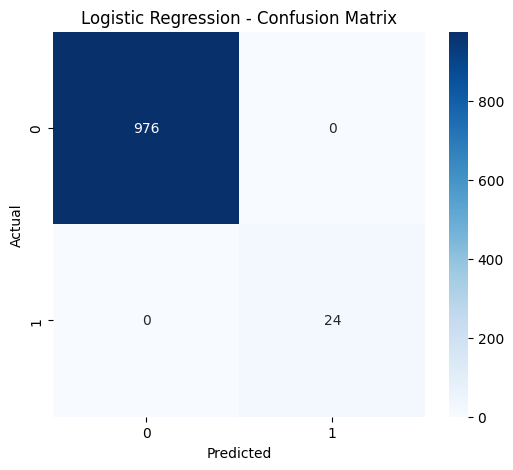

In [ ]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- **RANDOM FOREST**

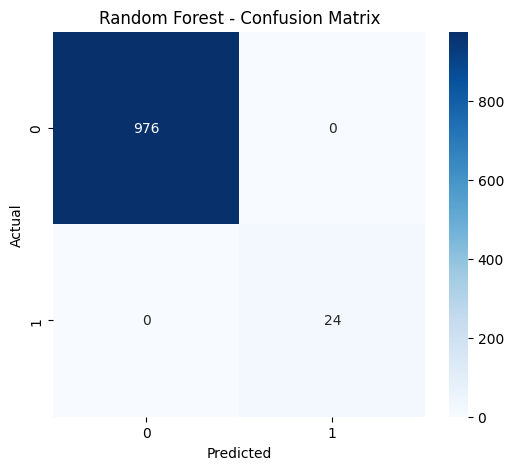

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**`ROC CURVES`**

<Figure size 800x600 with 0 Axes>

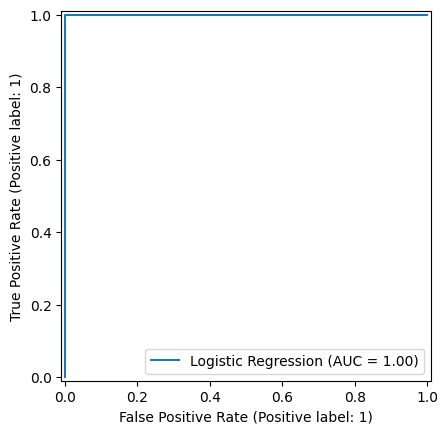

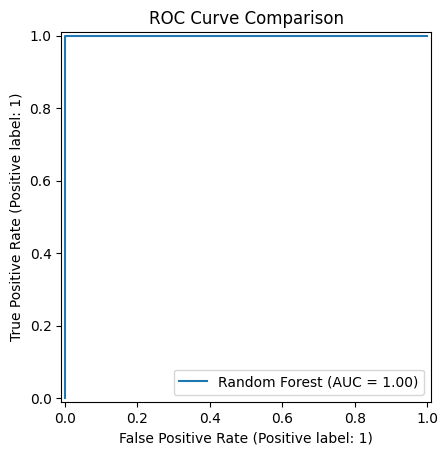

In [ ]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()

**`DETAILED CLASSIFICATION REPORTS`**

In [ ]:
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, lr_pred))

print("\nRANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, rf_pred))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       976
           1       1.00      1.00      1.00        24

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       976
           1       1.00      1.00      1.00        24

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



**`HYPERPARAMETER TUNING`**

In [ ]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Amount',
                                                                          'Quantity',
                                                                          'UnitPrice',
                                                                          'ItemsInCart',
                                                                          'AccountAgeDays',
                                                                          'TransactionsLast24h',
                                                                          'FailedTransactions...
                                                                         ['TransactionType',
                                                                          'PaymentMethod',
                                                                          'DeviceType',
                                                                          'Browser',
                                                                          'Location',
                                                                          'OrderStatus'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [ ]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(rf_grid.best_score_, 4))

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Cross-Validation ROC-AUC:
1.0


In [ ]:
best_rf = rf_grid.best_estimator_

tuned_rf_pred = best_rf.predict(X_test)
tuned_rf_prob = best_rf.predict_proba(X_test)[:, 1]

tuned_precision = precision_score(y_test, tuned_rf_pred)
tuned_recall = recall_score(y_test, tuned_rf_pred)
tuned_roc_auc = roc_auc_score(y_test, tuned_rf_prob)

print("Tuned Random Forest")
print("-------------------")
print("Precision:", round(tuned_precision, 4))
print("Recall:", round(tuned_recall, 4))
print("ROC-AUC:", round(tuned_roc_auc, 4))

Tuned Random Forest
-------------------
Precision: 1.0
Recall: 1.0
ROC-AUC: 1.0


**`FINAL MODEL COMPARISON`**

In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        tuned_recall
    ],
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc,
        tuned_roc_auc
    ]
})

final_results.round(4)

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0
2,Tuned Random Forest,1.0,1.0,1.0


**`IDENTIFYING THE BEST MODEL`**

In [ ]:
best_model_row = final_results.loc[
    final_results["ROC-AUC"].idxmax()
]

print("Best Model:", best_model_row["Model"])
print("Precision:", round(best_model_row["Precision"], 4))
print("Recall:", round(best_model_row["Recall"], 4))
print("ROC-AUC:", round(best_model_row["ROC-AUC"], 4))

Best Model: Logistic Regression
Precision: 1.0
Recall: 1.0
ROC-AUC: 1.0


**`FETAURE IMPORTANCE`**

In [ ]:
rf_model = best_rf.named_steps["model"]
preprocessor_fitted = best_rf.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
7,num__PreviousOrders,0.160479
15,num__TransactionHour,0.112157
19,num__VelocityScore,0.096245
17,num__IPRiskScore,0.095871
4,num__AccountAgeDays,0.091330
10,num__ShippingDistanceKm,0.068662
18,num__DeviceRiskScore,0.065630
6,num__FailedTransactions,0.063281
9,num__DistanceFromBillingKm,0.052728
22,num__CardAgeDays,0.041739


- **VISUALIZING TOP 15**

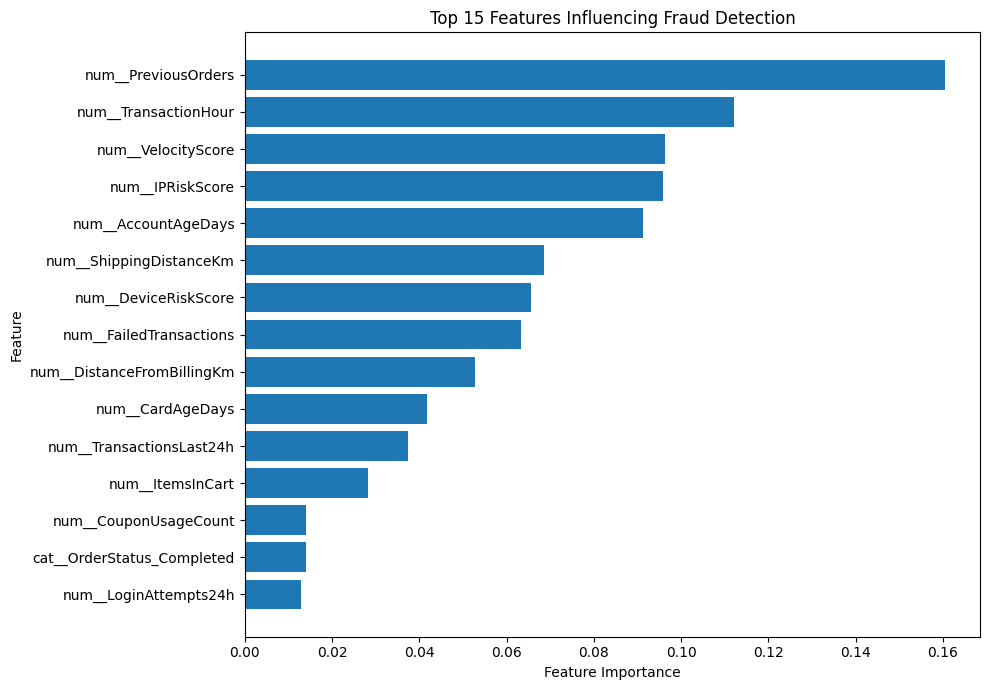

In [ ]:
top_features = importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Fraud Detection")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**`FINAL CONFUSION MATRIX`**

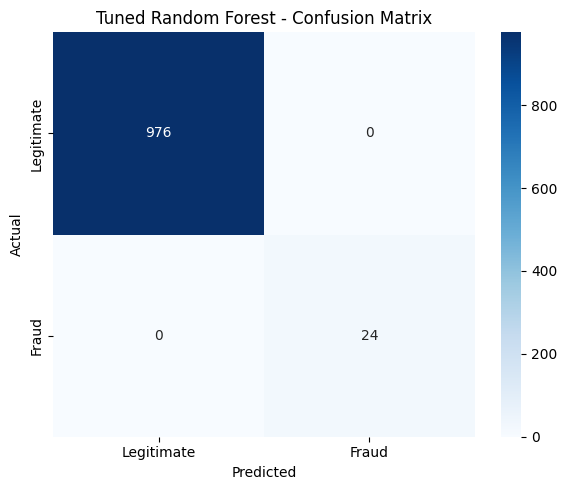

In [ ]:
cm = confusion_matrix(y_test, tuned_rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

**`FINAL ROC CURVE`**

<Figure size 800x600 with 0 Axes>

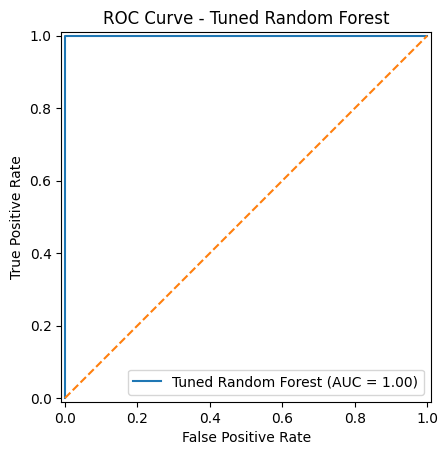

In [ ]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    tuned_rf_prob,
    name="Tuned Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

**`SAVING FINAL RESULTS`**

In [ ]:
final_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


**`SAVING THE FINAL MODEL`**

In [ ]:
import joblib

joblib.dump(
    best_rf,
    "fraud_detection_random_forest.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.
